In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import arviz as az
from patsy import dmatrix
import japanize_matplotlib

In [4]:
df = pd.read_csv("../data/marketing_AB.csv", index_col=0)
df_sub = pd.read_csv("../data/df_sub_cross_random_effect_v2.csv", index_col=0)
df["group_idx"] = df["test group"].map({"psa": 0, "ad": 1})
df["log_ads"] = np.log1p(df["total ads"])

print(len(df))
print(len(df_sub))

x_centered = (df_sub["log_ads"] - df["log_ads"].mean()) / df["log_ads"].std()
x_centered.values

588101
88215


array([ 0.23230312,  0.37318454,  0.37318454, ...,  1.3539536 ,
       -0.67049326,  1.09520149], shape=(88215,))

In [7]:
trace_spline = az.from_netcdf("../models/model_spline.nc")
trace_spline

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:                (chain: 4, draw: 1000, day_offset_raw_dim_0: 7,
│                                   hour_offset_raw_dim_0: 24, beta_spline_dim_0: 8,
│                                   day_effect_dim_0: 7, hour_effect_dim_0: 24,
│                                   p_dim_0: 88215)
│       Coordinates:
│         * chain                  (chain) int64 32B 0 1 2 3
│         * draw                   (draw) int64 8kB 0 1 2 3 4 5 ... 995 996 997 998 999
│         * day_offset_raw_dim_0   (day_offset_raw_dim_0) int64 56B 0 1 2 3 4 5 6
│         * hour_offset_raw_dim_0  (hour_offset_raw_dim_0) int64 192B 0 1 2 ... 21 22 23
│         * beta_spline_dim_0      (beta_spline_dim_0) int64 64B 0 1 2 3 4 5 6 7
│         * day_effect_dim_0       (day_effect_dim_0) int64 56B 0 1 2 3 4 5 6
│         * hour_effect_dim_0      (hour_effect_dim_0) int64 192B 0 1 2 3 ... 21 22 23
│         * p_dim_0                (p_dim_0) int64 706kB 0 1 2 3 ... 88212 88213 88214
│       Data variables: (12/13)
│           beta0                  (chain, draw) float64 32kB ...
│           beta1                  (chain, draw) float64 32kB ...
│           beta3                  (chain, draw) float64 32kB ...
│           day_offset_raw         (chain, draw, day_offset_raw_dim_0) float64 224kB ...
│           hour_offset_raw        (chain, draw, hour_offset_raw_dim_0) float64 768kB ...
│           beta_spline            (chain, draw, beta_spline_dim_0) float64 256kB ...
│           ...                     ...
│           sigma_day              (chain, draw) float64 32kB ...
│           sigma_hour             (chain, draw) float64 32kB ...
│           sigma_rw               (chain, draw) float64 32kB ...
│           day_effect             (chain, draw, day_effect_dim_0) float64 224kB ...
│           hour_effect            (chain, draw, hour_effect_dim_0) float64 768kB ...
│           p                      (chain, draw, p_dim_0) float64 3GB ...
│       Attributes:
│           created_at:                 2026-07-23T10:03:46.253886+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
│           inference_library:          numpyro
│           inference_library_version:  0.21.0
│           sampling_time:              499.81152
│           tuning_steps:               1000
├── Group: /sample_stats
│       Dimensions:          (chain: 4, draw: 1000)
│       Coordinates:
│         * chain            (chain) int64 32B 0 1 2 3
│         * draw             (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
│       Data variables:
│           acceptance_rate  (chain, draw) float64 32kB ...
│           step_size        (chain, draw) float64 32kB ...
│           diverging        (chain, draw) bool 4kB ...
│           energy           (chain, draw) float64 32kB ...
│           n_steps          (chain, draw) int64 32kB ...
│           tree_depth       (chain, draw) int64 32kB ...
│           lp               (chain, draw) float64 32kB ...
│       Attributes:
│           created_at:                 2026-07-23T10:03:46.485329+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:      (y_obs_dim_0: 88215)
│       Coordinates:
│         * y_obs_dim_0  (y_obs_dim_0) int64 706kB 0 1 2 3 4 ... 88211 88212 88213 88214
│       Data variables:
│           y_obs        (y_obs_dim_0) int64 706kB ...
│       Attributes:
│           created_at:                 2026-07-23T10:03:46.514097+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           sample_dims:                []
├── Group: /cons

knots: [-1.62283808 -1.0219754  -0.53686595  0.06399673  0.45580528  0.97404722
  4.26372395]


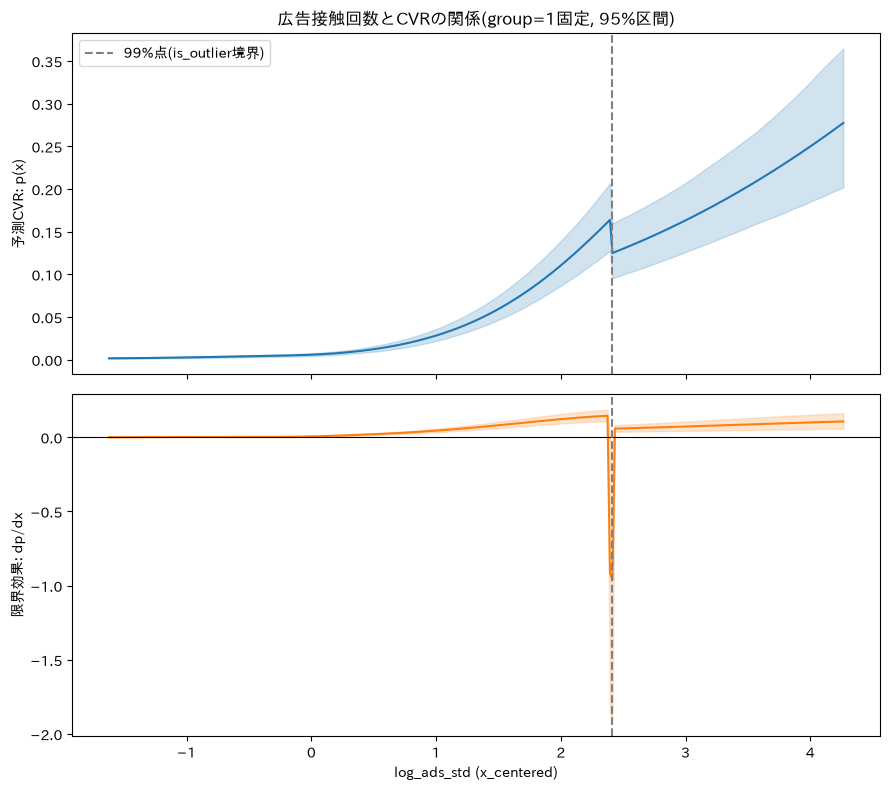

In [18]:
threshold = np.percentile(x_centered, 99)
x_grid = np.linspace(x_centered.min(), x_centered.max(), 300)
x_grid_for_spline = np.minimum(x_grid, threshold)
is_outlier_grid = (x_grid > threshold).astype(float)

num_knots = 5
knot_list = np.quantile(x_centered, np.linspace(0, 1, num_knots + 2))
print("knots:", knot_list)

B_grid = np.asarray(
    dmatrix(
    "bs(x, knots=knots, lower_bound=lb, upper_bound=ub, degree=3, include_intercept=False)-1",
    {"x": x_grid_for_spline, 
     "knots": knot_list[1:-1],
    "lb": x_centered.min(),
    "ub": x_centered.max()
        },
))
b_basis = B_grid.shape[1]

post = trace_spline.posterior
beta0_s = post["beta0"].values.reshape(-1)
beta1_s = post["beta1"].values.reshape(-1)
beta3_s = post["beta3"].values.reshape(-1)
beta_outlier_s = post["beta_outlier"].values.reshape(-1)
beta_spline_s = post["beta_spline"].values.reshape(-1, b_basis)

n_samples = beta0_s.shape[0]
group_fixed = 1

spline_effect_grid = beta_spline_s @ B_grid.T
spline_effect_grid = spline_effect_grid * (1 - is_outlier_grid)

logit_p_grid = (
    beta0_s[:, None]
    + beta1_s[:, None] * group_fixed
    + spline_effect_grid
    + beta_outlier_s[:, None] * is_outlier_grid[None, :]
    + beta3_s[:, None] * group_fixed * x_grid[None, :]
)
p_grid = 1 / (1 + np.exp(-logit_p_grid))

dx = x_grid[1] - x_grid[0]
dp_dx_grid = np.gradient(p_grid, dx, axis=1)

p_mean = p_grid.mean(axis=0)
p_lower, p_upper = np.percentile(p_grid, [2.5, 97.5], axis=0)

dp_mean = dp_dx_grid.mean(axis=0)
dp_lower, dp_upper = np.percentile(dp_dx_grid, [2.5, 97.5], axis=0)

fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

axes[0].plot(x_grid, p_mean, color="C0")
axes[0].fill_between(x_grid, p_lower, p_upper, alpha=0.2, color="C0")
axes[0].axvline(threshold, color="gray", linestyle="--", label="99%点(is_outlier境界)")
axes[0].set_ylabel("予測CVR: p(x)")
axes[0].legend()
axes[0].set_title("広告接触回数とCVRの関係(group=1固定, 95%区間)")

axes[1].plot(x_grid, dp_mean, color="C1")
axes[1].fill_between(x_grid, dp_lower, dp_upper, alpha=0.2, color="C1")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(threshold, color="gray", linestyle="--")
axes[1].set_ylabel("限界効果: dp/dx")
axes[1].set_xlabel("log_ads_std (x_centered)")

plt.tight_layout()
plt.show()

In [20]:
mask_valid = x_grid <= threshold
x_grid_valid = x_grid[mask_valid]
p_mean_valid = p_mean[mask_valid]
p_lower_valid = p_lower[mask_valid]
p_upper_valid = p_upper[mask_valid]
dp_mean_valid = dp_mean[mask_valid]
dp_lower_valid = dp_lower[mask_valid]
dp_upper_valid = dp_upper[mask_valid]

idx_inflection = np.argmax(dp_mean_valid)
x_inflection = x_grid_valid[idx_inflection]
print(f"変曲点(限界効果が最大): x_centered = {x_inflection:.3f}, 限界効果 = {dp_mean_valid[idx_inflection]:.4f}")

peak = dp_mean_valid[idx_inflection]
for frac in [0.5, 0.25, 0.1]:
    right_side = dp_mean_valid[idx_inflection:]
    below = np.where(right_side < peak * frac)[0]
    if len(below) > 0:
        x_thresh = x_grid_valid[idx_inflection:][below[0]]
        print(f"限界効果がピークの{frac*100:.0f}%まで低下する点: x_centered = {x_thresh:.3f}")
    else:
        print(f"限界効果がピークの{frac*100:.0f}%まで低下する点: threshold手前では未到達")
    

変曲点(限界効果が最大): x_centered = 2.374, 限界効果 = 0.1454
限界効果がピークの50%まで低下する点: x_centered = 2.393
限界効果がピークの25%まで低下する点: x_centered = 2.393
限界効果がピークの10%まで低下する点: x_centered = 2.393


In [21]:
log_ads_mean = df["log_ads"].mean()
log_ads_std_val = df["log_ads"].std()

x_inflection_raw = x_inflection * log_ads_std_val + log_ads_mean
ads_count_inflection = np.exp(x_inflection_raw)
print(f"変曲点: log_ads = {x_inflection_raw:.3f}, 広告回数 ≈ {ads_count_inflection:.1f}回")

変曲点: log_ads = 5.304, 広告回数 ≈ 201.0回


In [22]:
idx_check = idx_inflection
print(f"x={x_grid_valid[idx_check]:.3f}での dp/dx: 平均={dp_mean_valid[idx_check]:.4f}, "
      f"95%区間=[{dp_lower_valid[idx_check]:.4f}, {dp_upper_valid[idx_check]:.4f}]")

# 比較のため、データが十分にある領域(例えば90%点=1.296付近)も見てみる
idx_90pct = np.argmin(np.abs(x_grid_valid - 1.296))
print(f"x={x_grid_valid[idx_90pct]:.3f}(90%点付近)での dp/dx: 平均={dp_mean_valid[idx_90pct]:.4f}, "
      f"95%区間=[{dp_lower_valid[idx_90pct]:.4f}, {dp_upper_valid[idx_90pct]:.4f}]")

x=2.374での dp/dx: 平均=0.1454, 95%区間=[0.1095, 0.1859]
x=1.291(90%点付近)での dp/dx: 平均=0.0648, 95%区間=[0.0501, 0.0834]


In [23]:
# 安全な範囲: 95%点までに制限(99%点よりさらに手前で切る)
safe_boundary = np.percentile(x_centered, 95)
mask_safe = x_grid <= safe_boundary

x_grid_safe = x_grid[mask_safe]
dp_mean_safe = dp_mean[mask_safe]
dp_lower_safe = dp_lower[mask_safe]
dp_upper_safe = dp_upper[mask_safe]

ci_width_safe = dp_upper_safe - dp_lower_safe
print("安全域での信用区間幅の推移(先頭・中間・末尾):")
print(ci_width_safe[[0, len(ci_width_safe)//2, -1]])

安全域での信用区間幅の推移(先頭・中間・末尾):
[0.00090794 0.00548949 0.04825499]


In [25]:
# --- 安全域(95%点まで)のdp_lowerを使って、C/V比ごとの損益分岐点を探る ---

# 検討するC/V比率(コスト/CV価値)のシナリオ
# 比率が小さいほど「CVの価値がコストに比べて高い」→もっと多く配信してもペイする
cv_cost_ratios = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

results = []
for ratio in cv_cost_ratios:
    below = np.where(dp_lower_safe < ratio)[0]
    if len(below) > 0:
        idx_cutoff = below[0]
        x_cutoff = x_grid_safe[idx_cutoff]
    else:
        idx_cutoff = len(x_grid_safe) - 1
        x_cutoff = x_grid_safe[idx_cutoff]

    x_cutoff_raw = x_cutoff * log_ads_std_val + log_ads_mean
    ads_count_cutoff = np.exp(x_cutoff_raw)

    results.append({
    "C/V比率": ratio,
    "x_centered": x_cutoff,
    "推定広告回数キャップ": ads_count_cutoff
    })

df_sensitivity = pd.DataFrame(results)
print(df_sensitivity)

   C/V比率  x_centered  推定広告回数キャップ
0  0.001   -1.622838         2.0
1  0.005   -1.622838         2.0
2  0.010   -1.622838         2.0
3  0.020   -1.622838         2.0
4  0.050   -1.622838         2.0
5  0.100   -1.622838         2.0


In [30]:
# ピーク(変曲点)のインデックスを安全域の中で探す
idx_peak_safe = np.argmax(dp_mean_safe)
print(f"安全域内でのピーク位置: x={x_grid_safe[idx_peak_safe]:.3f}, dp/dx={dp_mean_safe[idx_peak_safe]:.4f}")

cv_cost_ratios = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1]

results = []
for ratio in cv_cost_ratios:
    # ピークより右側だけで探索する
    right_side_lower = dp_lower_safe[idx_peak_safe:]
    right_side_x = x_grid_safe[idx_peak_safe:]

    below = np.where(right_side_lower < ratio)[0]
    if len(below) > 0:
        idx_cutoff = below[0]
        x_cutoff = right_side_x[idx_cutoff]
        found = True
    else:
        x_cutoff = right_side_x[-1]
        found = False

    x_cutoff_raw = x_cutoff * log_ads_std_val + log_ads_mean
    ads_count_cutoff = np.exp(x_cutoff_raw)

    results.append({
        "C/V比率": ratio,
        "x_centered": x_cutoff,
        "推定広告回数キャップ": ads_count_cutoff,
        "安全域内で発見": found
    })

df_sensitivity = pd.DataFrame(results)
print(df_sensitivity)

安全域内でのピーク位置: x=1.665, dp/dx=0.0951
   C/V比率  x_centered  推定広告回数キャップ  安全域内で発見
0  0.001    1.664974   88.758887    False
1  0.005    1.664974   88.758887    False
2  0.010    1.664974   88.758887    False
3  0.020    1.664974   88.758887    False
4  0.050    1.664974   88.758887    False
5  0.100    1.664974   88.758887     True


In [31]:
# より保守的な安全域(90%点)で再定義
safe_boundary_v2 = np.percentile(x_centered, 90)
mask_safe_v2 = x_grid <= safe_boundary_v2

x_grid_safe_v2 = x_grid[mask_safe_v2]
dp_mean_safe_v2 = dp_mean[mask_safe_v2]
dp_lower_safe_v2 = dp_lower[mask_safe_v2]

idx_peak_safe_v2 = np.argmax(dp_mean_safe_v2)
print(f"90%点までの安全域でのピーク位置: x={x_grid_safe_v2[idx_peak_safe_v2]:.3f}")
print(f"90%点(右端)自体でのdp/dx: {dp_mean_safe_v2[-1]:.4f}, 95%区間=[{dp_lower_safe_v2[-1]:.4f}, {np.percentile(dp_dx_grid, 97.5, axis=0)[mask_safe_v2][-1]:.4f}]")

90%点までの安全域でのピーク位置: x=1.291
90%点(右端)自体でのdp/dx: 0.0648, 95%区間=[0.0501, 0.0834]


In [32]:
ads_count_90pct = np.exp(safe_boundary_v2 * log_ads_std_val + log_ads_mean)
print(f"90%点の広告回数: {ads_count_90pct:.1f}回")

90%点の広告回数: 58.0回


# ベイズA/Bテスト分析

対象データ: [Marketing A/B Testing (Kaggle)](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing)
リポジトリ: https://github.com/karahashimanato/bayesian-A-B-testing

---

## 1. 分析の出発点:モデル比較

3つの候補モデルを LOO / AUC-ROC / Brier score で比較。

| モデル | 内容 |
|---|---|
| `no_hierarchy` | 単純ロジスティック回帰 |
| `day_hour_hierarchy` | day/hourの階層(部分プーリング)構造を追加 |
| `day_hour_hierarchy`(最終形) | 上記 + `log_ads`の非線形性 + 外れ値ダミー |

初期比較では `day_hour_hierarchy` がLOOで明確に優位(weight=0.98)。ただしAUC-ROC/Brierの改善は僅かで、**「LOOでは明確な差、集計指標ではほぼ差なし」という食い違い**が最初の疑問点になった。

---

## 2. キャリブレーション診断でS字型のズレを発見

予測確率でビン分けしたキャリブレーション曲線は対角線にほぼ重なって見えたが、**`log_ads_std`(広告接触回数の標準化対数)の値そのものでビン分けし、z値((実測CVR−予測CVR)/SE)を計算**したところ、明確なパターンが見つかった:

- 低ads帯: ほぼ0(問題なし)
- **中間帯: z = -5〜-9(モデルが一貫して過大評価)**
- 高ads帯: z = +3〜+4(モデルが過小評価)

→ **「中間で過大評価、両端で過小評価」というS字型の系統的ズレ**。ノイズでは説明できない規模。

---

## 3. 二次項による対処とその限界

**仮説**: `log_ads_std`に対する線形の対数オッズという仮定が誤り。

**対処**: 主効果に二次項 `beta2b * x^2` を追加。

- 事前予測チェックで `sigma_beta2b` を線形項とのスケール比較から逆算(≈0.07〜0.15)。
- サンプリング診断(r_hat, ESS, divergence=0)はクリア。感度チェックでも事後平均は安定。
- **LOOでは明確に改善(elpd_diff=-50〜-130)**。

**しかし**: 同じz値診断をやり直すと、**中間帯のズレはほぼ変わらず、むしろ元々問題なかった低ads側・高ads側に新たなズレが発生**。

**原因**: 二次関数は偶関数(左右対称)。非対称なズレ(中間だけ過大評価)を「対称にしか曲げられない」道具で直そうとしたため、山を削ると両端も一緒に削られてしまった。→ **道具(関数形)と問題(非対称性)のミスマッチ**という教訓。

**LOOで「改善した」と判定された理由**: LOOは対数尤度の総和。低ads側は実測確率がほぼ0で `log(1-p)≈-p` となりズレの影響が小さい一方、中間帯は絶対確率・サンプル数ともに大きく対数尤度への寄与が大きい。**集計指標は場所によって感度が均一ではない**ため、局所的な悪化を検出しにくい。

---

## 4. スプライン(P-スプライン)への切り替え

非対称な非線形性を捉えるため、B-スプライン + ランダムウォーク事前分布(P-スプライン)を導入。実装過程で複数の非識別性の罠に遭遇し、そのたびに事前予測チェックと感度分析で切り分けた。

### 罠1: `init_dist`のデフォルトが広すぎる
`GaussianRandomWalk`の起点(`init_dist`)を明示しないと、10次元すべてがほぼ同じ巨大な分散(sd≈104)を持ち、`beta0`(切片)と`beta_spline`の間で**水準の奪い合い(非識別性)**が発生。
→ `init_dist=Normal(0, 0.01)`で起点をほぼ0に固定し、水準はbeta0、形状はbeta_splineという役割分担に整理。

### 罠2: knot配置のトレードオフ
- quantile knot(データ件数を均等化)→ 高ads側の1区間だけ幅3.3という異様に広い区間になり、`beta_spline`の該当係数だけ突出。
- equidistant knot(x軸を均等化)→ 高ads側の区間サンプル数がn=25まで枯渇。
どちらも一長一短で、knot数を増やしても解決しなかった。

### 発見: 上位1%が外れ値ではなく「価値ある高頻度層」
99%点(x=2.41)を超えるデータ(n=870, 全体の0.99%)を調べたところ、CVRは通常の2.5%に対し**15.4%(6倍)**。これは単なる統計的外れ値ではなく、ビジネス上重要な高頻度接触層と判断。除外ではなく、以下の設計で対応:

- スプライン計算に使う`x`を99%点でクリップ(`x_for_spline = min(x, threshold)`)→ knotの最終区間の幅が3.3→1.43に縮小
- 99%点超のデータには`is_outlier`ダミー変数(`beta_outlier`)で「水準の底上げ」を別枠として持たせる

### 罠3: スプラインとダミーの重複
外れ値グループ870件は`x_for_spline`が全て同一値になるため、`spline_effect`(境界の基底関数値)と`beta_outlier`が**同じ役割を重複して持ってしまい**、divergence=171という大量のサンプリング失敗が発生。
→ `spline_effect * (1 - is_outlier) + beta_outlier * is_outlier`という形で、**行ごとにどちらか一方だけが効くよう完全分離**して解決(divergence=0)。

### 番外編: 変数の再定義漏れによるデバッグ
モデルをv1→v2→v3→v4と改良する過程で、コードは修正しても古いtrace/変数を参照し続けてしまい、何度も「同じ結果」が再現される事象が発生。ノートブック全体のセル一覧を出して原因を特定し、最終的に新しいセル(`model_final`)としてクリーンに再構築することで解消。**モデルの技術的な議論と、ノートブックの実行状態管理は別問題として切り分ける必要がある**という実務上の教訓。

### 最終結果
z値診断で、10ビン中9ビンが |z| < 1.1 まで改善(以前は最大 |z| ≈ 9.4)。LOO(weight=0.98)・AUC-ROC(0.8573)・Brier(0.0231)も全て最良値を記録し、**集計指標とビンごとの診断が両方とも一貫して改善**したことから、局所的な過適合ではなく本物の非線形構造を捉えられたと判断。

---

## 5. ビジネス意思決定への接続:広告接触回数の最適化

### 曲線と限界効果(dp/dx)の可視化
事後分布全体を使って `p(x)` とその数値微分 `dp/dx` を95%信用区間付きでプロット。

**注意点**: `threshold`(99%点)の境界で `spline_effect → beta_outlier` へ切り替わるため、曲線に人工的な「谷」(不連続)が生じる。これはモデル構造上のアーティファクトであり、実際の現象ではないと判断 → **意思決定の対象範囲は99%点より手前に限定**。

### 「変曲点」の罠
限界効果が最大になる点(変曲点)は x=2.374(広告回数≈201回)と算出されたが、この点は99%点のすぐ近くでデータが疎な領域。信用区間幅を比較すると、変曲点(0.076)は安定領域である90%点付近(0.033)の2倍以上広く、**過適合・端の不安定さによる見せかけの結果**と判断し、採用を見送った。

### 感度分析(C/V比率シナリオ)
「保守的に見てもペイする」水準を、信用区間下限(`dp_lower`)とコスト/CV価値比率(C/V比)の比較で探索。

- 当初、探索を配列の先頭(x最小値)から行い、**「まだ効果が立ち上がる前の助走区間」を飽和と誤検出**する問題が発生 → ピーク(変曲点)より右側だけで探索するよう修正。
- 安全域を95%点→90%点と切り下げても、**その境界(右端)自体がピーク位置と一致してしまい、減衰する様子を一度も観測できなかった**。

### 最終結論
- データが十分に存在する範囲(90%点 ≈ **58回**)では、広告接触回数とCVRの間に強い正の相関があり、**効果の減衰(飽和)の兆候は一切確認されなかった**。
- 「〇〇回が上限」という一点の数字による結論は、データが支持しない(過剰主張)ため採用しない。

### 因果性に関する重要な限界(最終確認)
データソース([Kaggle: Marketing A/B Testing](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing))を確認したところ:

- **`test group`(ad/psa)はランダム化割り当て** → `beta1`(group主効果)は比較的自信を持って**因果効果**と言える
- **`total ads`(接触回数)はランダム化されていない観測変数**(広告配信アルゴリズムやユーザー行動の結果) → 接触回数とCVRの関係は**相関関係**であり、「配信回数を増やせばCVRが上がる」という**介入としての因果効果ではない**可能性が高い(逆の因果・交絡の余地あり)

**アクションへの反映**:
- ❌「配信量を増やすことへの投資根拠」としては使わない(因果的主張の裏付けが不足)
- ✅「高頻度接触になりやすい優良ユーザー層を予測・特定するための知見」として活用する(予測的セグメンテーション)
- 真の因果効果(配信量を増やせばCVRが上がるか)を確認するには、**接触頻度そのものをランダムに操作する実験(頻度キャップのA/Bテスト)**が必要

---

## 今回得られた主な方法論的教訓

1. **集計指標(LOO, AUC, Brier)は場所を選ばず均等に効くわけではない** — 対数尤度は確率が0付近だと鈍感になるなど、指標ごとの感度特性を理解した上で使う
2. **対称な道具(二次項)で非対称な問題を直そうとすると、別の場所に歪みが生む** — 関数形の性質(偶関数・奇関数)と、直したい問題の形状を照らし合わせる
3. **モデルの複雑化(スプライン等)は新しい非識別性を生みやすい** — 水準(切片)を複数のパラメータが奪い合う構造にならないよう、役割分担を明示する
4. **「表面的改善 ≠ 根本問題の解決」は事前予測チェックのスケール調整でも起きる** — 極値(min/max)だけでなく、割合や信用区間幅で判断する
5. **外れ値は除外する前に中身を見る** — 統計的な外れ値が、ビジネス上最も価値あるセグメントである可能性がある
6. **意思決定に使う推定は、信用区間が安定している範囲に限定する** — 変曲点やピークが「データの疎な端」に出た場合は、過適合を疑う
7. **相関関係から意思決定を導く際は、変数がランダム化されているかどうかを必ず確認する** — ランダム化された変数(group)とそうでない変数(total ads)とでは、結論の強さ(因果 vs 相関)が根本的に異なる

---

## 次に着手できそうなトピック(未着手)

- 高頻度接触層(`beta_outlier`)を用いた優良ユーザーの予測的ターゲティング設計
- 曜日・時間帯別(`day_effect`, `hour_effect`)の配信最適化
- group間(ad vs psa)の異質性を踏まえた `beta3`(交互作用)の解釈の深掘り
- 接触頻度の因果効果を検証するための実験設計(頻度キャップA/Bテスト)の立案
